
# <span style="color:rgb(213,80,0)">Least\-Squares Beamformer</span>

Least\-squares beamformer design can be applied to an arbitrary array manifold.


Consider an M\-element uniform linear array.


In [1]:
lambda = 3e-2;
M = 12;
position = (0:M-1).' * lambda/2;



Create the steering vector


In [2]:
steering_vector = @(theta) ...
    exp(-1j*2*pi/lambda * position * sind(theta));

theta0 = 0;
theta_s_0_left  = linspace(-90, -20, 50);
theta_s_0_right = linspace( 20,  90, 50);
theta_s_0 = [theta_s_0_left,theta0,theta_s_0_right];

A = steering_vector(theta_s_0);


Assume the desired ideal beam pattern is ${P_d (\theta )}=[p_{d1} (\theta ),p_{d2} (\theta ),...,p_{dk} (\theta )]$ . In weighted least squares, our goal is to minimize the mean\-square error between the designed beam pattern ${P(\theta )}$ and the target beam pattern, i.e.,


$$\min_w [{P(\theta )-{P_d (\theta )}}]diag({v(\theta )})[{P(\theta )-{P_d (\theta )}}]^H$$

where


 ${P(\theta )}=w^H {A(\theta )}$ , and


$${A(\theta )}=\left\lbrack a(\theta_1 ),a(\theta_2 ),\cdots ,a(\theta_K )\right\rbrack =\left\lbrack \begin{array}{cccc} 1 & 1 & \cdots  & 1\\ e^{-j\frac{2\pi d_2 }{\lambda }\sin \theta_1 }  & e^{-j\frac{2\pi d_2 }{\lambda }\sin \theta_2 }  & \cdots  & e^{-j\frac{2\pi d_2 }{\lambda }\sin \theta_K } \\ \vdots  & \vdots  & \ddots  & \vdots \\ e^{-j\frac{2\pi d_M }{\lambda }\sin \theta_1 }  & e^{-j\frac{2\pi d_M }{\lambda }\sin \theta_2 }  & \cdots  & e^{-j\frac{2\pi d_M }{\lambda }\sin \theta_K }  \end{array}\right\rbrack$$

Define the cost function


$$J(w)=[{P(\theta )-{P_d (\theta )}}]diag({v(\theta )})[{P(\theta )-{P_d (\theta )}}]^H$$

Let $diag({v(\theta )})=V$


Expanding the cost function gives


$$\begin{array}{l} J(w)=[{P(\theta )-{P_d (\theta )}}]V[{P(\theta )-{P_d (\theta )}}]^H \\ =[w^H {A(\theta )}-{P_d (\theta )}]V[{{A(\theta )}}^H w-{{P_d (\theta )}}^H ]\\ =w^H AVA^H w-w^H AV{{P_d }}^H -{P_d }VA^H w+{P_d }V{P_d } \end{array}$$

This is a quadratic function of $w$ . It is clearly convex. Differentiating with respect to $w^H$ and setting the derivative to zero gives the optimal solution.


$$\frac{\partial J}{\partial w^H }=AVA^H w-AV{{P_d }}^H =0$$

The optimal weights are therefore


$$w_{opt} =(AVA^H )^{-1} AV{{P_d }}^H$$

The weighting matrix here is specified manually rather than estimated from the noise covariance matrix. Following the definition in the textbook, V is diag(\[0.5,0.5,...,0.5\]).


 ${P_d }$ The desired response is 1 at $0^{\circ }$ and 0 elsewhere.


In [ ]:
v = repmat(0.5,[length(theta_s_0),1]);
V = diag(v,0);
Pd = [zeros([1,length(theta_s_0_left)]),1,zeros([1,length(theta_s_0_right)])];

Pd = 1×101 double
     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0
...


The optimal weights are


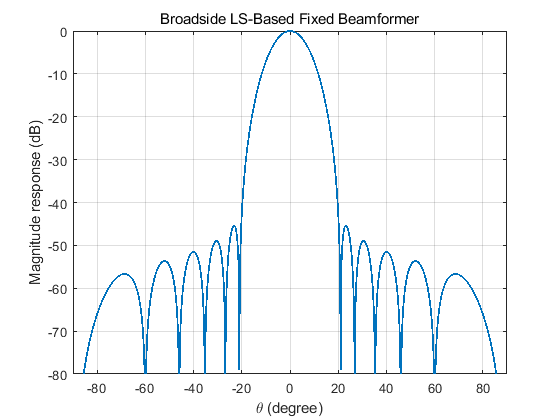

In [4]:
w_opt = (A*V*A')\(A*V*Pd');
theta_plot = -90:0.1:90;
D_plot = steering_vector(theta_plot);     % M×Ntheta
P_LS_0 = w_opt'*D_plot;
BP_LS_0 = 20*log10( ...
    abs(P_LS_0)/max(abs(P_LS_0)) + eps);
figure;
plot(theta_plot, BP_LS_0, 'LineWidth', 1.3);
grid on;
xlim([-90 90]);
ylim([-80 0]);

xlabel('\theta (degree)');
ylabel('Magnitude response (dB)');
title('Broadside LS-Based Fixed Beamformer');


This demonstrates that weighted least squares and the method in the textbook are equivalent.

